# PDAN8412/w Part 1: Recurrent Neural Networks
## Author identification using an LSTM

**Dataset:** TextAge historical text corpus from Kaggle  
**Task:** Predict the author of an unseen text passage from writing style.

This notebook uses **Apache Spark for loading, data-quality checks, cleaning and exploratory analysis**. The neural network is trained in **PyTorch**, which is permitted because the Part 1 brief requires the model to be trained in Python but does not prescribe a specific deep-learning library.

The analysis is designed so that the notebook and report can be read together. All important tables and figures are also saved to the `part1_outputs` folder for insertion into the final report.


## Before running the notebook

Run the one-time Anaconda Prompt setup supplied with this notebook before opening Jupyter. The notebook assumes that the `pdan8412` environment contains PySpark, PyTorch, pandas, scikit-learn and matplotlib.

Place `archive.zip` in the **same folder as this notebook**. The first data cell extracts `textage_large.csv` automatically.

A work-aware train, validation and test split is used. Passages from the same author and title are kept in one partition to reduce leakage from book-specific vocabulary.


In [1]:
# Cell 1: Environment pre-flight check

import sys
import os
import subprocess
import importlib.util
from pathlib import Path

required_packages = {
    "pyspark": "pyspark",
    "torch": "torch",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib"
}

missing = [
    install_name
    for import_name, install_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

java_check = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True
)

if java_check.returncode == 0:
    java_text = java_check.stderr.splitlines()[0] if java_check.stderr else java_check.stdout.splitlines()[0]
    print("Java:", java_text)
else:
    raise RuntimeError(
        "Java is not visible to this Jupyter kernel. "
        "Close Jupyter, set JAVA_HOME in Anaconda Prompt, and launch Jupyter again."
    )

if missing:
    raise RuntimeError(
        "Missing Python packages: "
        + ", ".join(missing)
        + ". Install them in the pdan8412 Anaconda environment before continuing."
    )

print("Environment check passed.")


Python executable: C:\Users\anphewa\AppData\Local\anaconda3\python.exe
Python version: 3.13.9
Java: openjdk version "17.0.15" 2025-04-15
Environment check passed.


In [2]:
# Cell 2: Imports and reproducibility

import json
import random
import re
import time
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUTPUT_DIR = Path("part1_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("PyTorch version:", torch.__version__)
print("Outputs will be saved to:", OUTPUT_DIR.resolve())


PyTorch version: 2.14.0+cpu
Outputs will be saved to: C:\Users\anphewa\PDAN8412 Part 1\part1_outputs


## 1. Dataset selection and suitability

TextAge is suitable for this task because it provides the actual text together with author and title labels. Authorship attribution is a supervised multiclass classification problem where the model receives a passage and predicts one of several candidate authors.

The downloaded large file is checked directly rather than relying only on the Kaggle data card. This is important because dataset documentation can differ slightly from the file that is actually downloaded.

The analysis focuses on seven frequent named authors. `Unknown` is excluded because it is not a meaningful author class. Metadata such as title, date and category is retained for EDA but **not supplied to the model**, because those fields could give the model shortcuts instead of requiring it to learn patterns in the writing itself.


In [3]:
# Cell 3: Extract the large CSV from archive.zip

ZIP_PATH = Path("archive.zip")
DATA_DIR = Path("textage_data")
CSV_PATH = DATA_DIR / "textage_large.csv"

if not ZIP_PATH.exists() and not CSV_PATH.exists():
    raise FileNotFoundError(
        "archive.zip was not found. Put archive.zip in the same folder as this notebook."
    )

DATA_DIR.mkdir(exist_ok=True)

if not CSV_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        if "textage_large.csv" not in zf.namelist():
            raise FileNotFoundError("textage_large.csv is not inside archive.zip.")
        zf.extract("textage_large.csv", DATA_DIR)

print("Dataset ready:", CSV_PATH.resolve())


Dataset ready: C:\Users\anphewa\PDAN8412 Part 1\textage_data\textage_large.csv


In [4]:
# Cell 4: Start a local Spark session

# Force Spark workers to use the same Python interpreter as this Jupyter kernel.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("PDAN8412_TextAge_Part1")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
spark.range(5).show()


Spark version: 4.2.0
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



## 2. Load and profile the complete dataset

Spark is used first because the assessment requires Spark to be used for the analysis. The full CSV is loaded before any author filtering so that the source dataset can be evaluated for size, schema, completeness and composition.


In [5]:
# Cell 5: Load the complete TextAge CSV with Spark

spark_csv_path = str(CSV_PATH.resolve()).replace("\\", "/")

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("encoding", "UTF-8")
    .option("mode", "PERMISSIVE")
    .csv(spark_csv_path)
)

df = df.toDF(*[
    c.strip().lower().replace(" ", "_")
    for c in df.columns
])

print("Rows:", df.count())
print("Columns:", len(df.columns))
print("Column names:", df.columns)
df.printSchema()
df.show(5, truncate=90)


Rows: 91918
Columns: 7
Column names: ['text', 'category', 'date', 'title', 'author', 'decade', 'text_length']
root
 |-- text: string (nullable = true)
 |-- category: string (nullable = true)
 |-- date: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- author: string (nullable = true)
 |-- decade: integer (nullable = true)
 |-- text_length: integer (nullable = true)

+------------------------------------------------------------------------------------------+--------+----+------------------------------------------------------------------------------------+--------------+------+-----------+
|                                                                                      text|category|date|                                                                               title|        author|decade|text_length|
+------------------------------------------------------------------------------------------+--------+----+-------------------------------------------------------

In [6]:
# Cell 6: Complete dataset profile

profile = df.select(
    F.count("*").alias("rows"),
    F.countDistinct("author").alias("unique_authors"),
    F.countDistinct("title").alias("unique_titles"),
    F.countDistinct("category").alias("unique_categories"),
    F.min("date").alias("earliest_date"),
    F.max("date").alias("latest_date")
)

profile.show(truncate=False)


+-----+--------------+-------------+-----------------+-------------+-----------+
|rows |unique_authors|unique_titles|unique_categories|earliest_date|latest_date|
+-----+--------------+-------------+-----------------+-------------+-----------+
|91918|667           |914          |15               |1473         |1928       |
+-----+--------------+-------------+-----------------+-------------+-----------+



In [7]:
# Cell 7: Missing and blank values

quality_columns = [
    "text", "category", "date", "title",
    "author", "decade", "text_length"
]

missing_expressions = []

for c in quality_columns:
    missing_expressions.append(
        F.sum(
            F.when(
                F.col(c).isNull()
                | (F.trim(F.col(c).cast("string")) == ""),
                1
            ).otherwise(0)
        ).alias(c)
    )

df.select(*missing_expressions).show(truncate=False)


+----+--------+----+-----+------+------+-----------+
|text|category|date|title|author|decade|text_length|
+----+--------+----+-----+------+------+-----------+
|0   |0       |0   |0    |0     |0     |0          |
+----+--------+----+-----+------+------+-----------+



+-------------------+-----+
|author             |count|
+-------------------+-----+
|charles-dickens    |3182 |
|unknown            |2909 |
|william-caxton     |2701 |
|anthony-trollope   |2161 |
|william-shakespeare|1519 |
|Defoe-Daniel       |1489 |
|rudyard-kipling    |1368 |
|elizabeth-cleghorn |1204 |
|John-Bourchier     |1080 |
|thomas-hardy       |953  |
|jane-austen        |916  |
|shikibu-murasaki   |891  |
|Robertson-William  |863  |
|wiillam-caxton     |700  |
|Douglas-Robert-Sir |684  |
|john-milton        |671  |
|george-mackenzie   |658  |
|david-herbert      |599  |
|david-graham       |596  |
|henry-james        |556  |
+-------------------+-----+
only showing top 20 rows


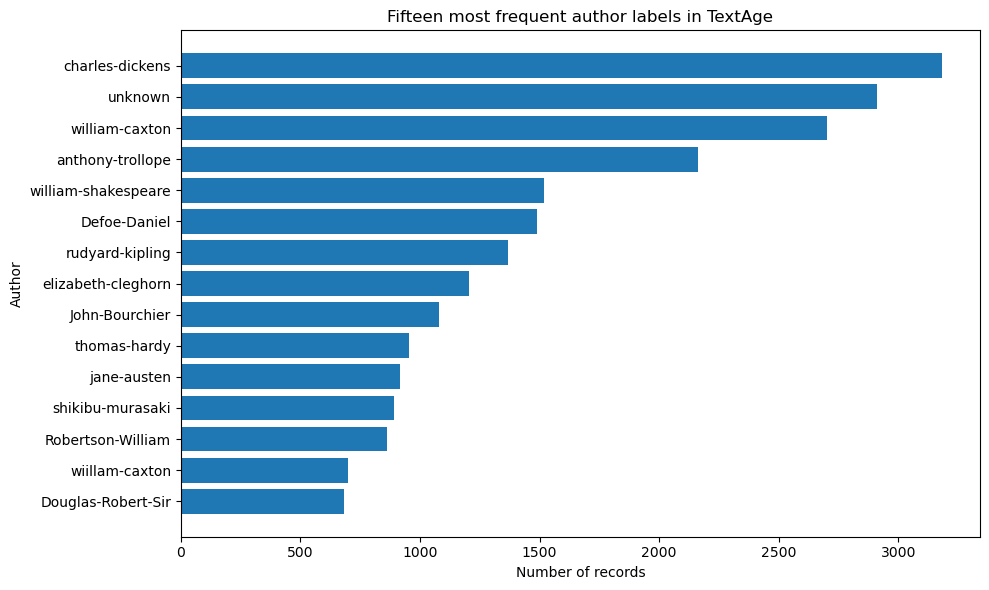

In [8]:
# Cell 8: Most frequent authors in the complete source dataset

author_counts = (
    df.groupBy("author")
    .count()
    .orderBy(F.desc("count"))
)

author_counts.show(20, truncate=False)

top_authors_pd = author_counts.limit(15).toPandas()

plt.figure(figsize=(10, 6))
plt.barh(
    top_authors_pd["author"][::-1],
    top_authors_pd["count"][::-1]
)
plt.xlabel("Number of records")
plt.ylabel("Author")
plt.title("Fifteen most frequent author labels in TextAge")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_01_top_authors.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


+-----------+-----+
|category   |count|
+-----------+-----+
|Book       |85929|
|Poem       |1391 |
|Treaty     |1168 |
|Essay      |1094 |
|Letter     |630  |
|Sermon     |478  |
|Document   |438  |
|Novel      |396  |
|Act        |127  |
|Dialogue   |91   |
|Apology    |87   |
|Report     |43   |
|Application|36   |
|Law        |6    |
|Prayer     |4    |
+-----------+-----+



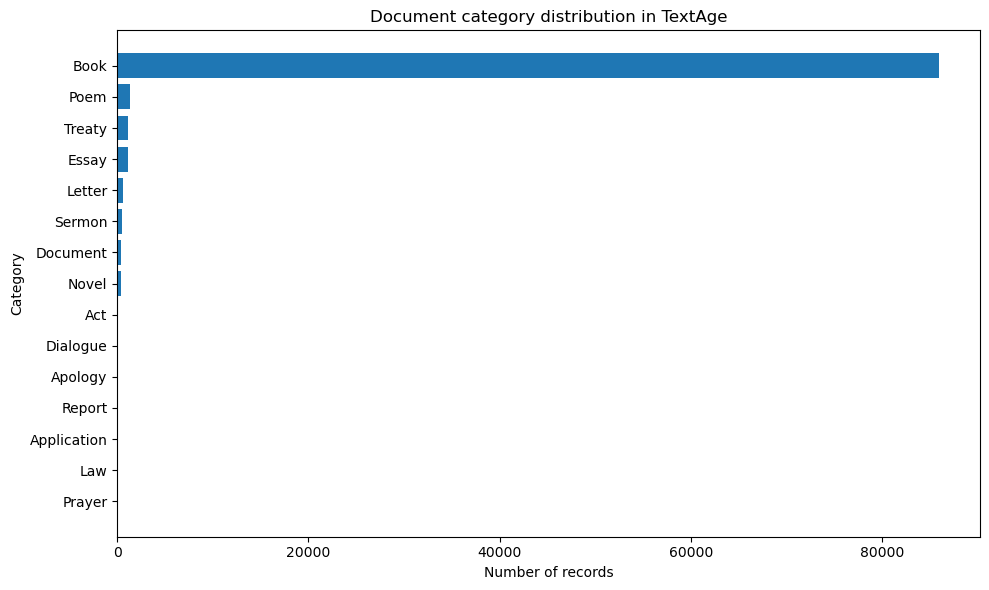

In [9]:
# Cell 9: Category distribution in the complete source dataset

category_counts = (
    df.groupBy("category")
    .count()
    .orderBy(F.desc("count"))
)

category_counts.show(truncate=False)

category_pd = category_counts.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(
    category_pd["category"][::-1],
    category_pd["count"][::-1]
)
plt.xlabel("Number of records")
plt.ylabel("Category")
plt.title("Document category distribution in TextAge")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_02_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### EDA interpretation

The complete dataset establishes whether the source is large enough and whether it contains useful author labels. The category graph also shows whether the dataset is dominated by one document type.

These observations matter because a model may learn document or historical-period differences in addition to personal writing style. This is treated as a limitation later in the report rather than ignored.


## 3. Select frequent named authors

The modelling subset uses seven frequent named authors:

1. Charles Dickens  
2. William Caxton  
3. Anthony Trollope  
4. William Shakespeare  
5. Daniel Defoe  
6. Rudyard Kipling  
7. Elizabeth Cleghorn Gaskell  

This keeps the task large enough to exceed the 10,000-record requirement while avoiding a 667-class problem that would be unnecessarily large for the portfolio.


In [10]:
# Cell 10: Selected author labels as they appear in the actual CSV

SELECTED_AUTHORS = [
    "charles-dickens",
    "william-caxton",
    "anthony-trollope",
    "william-shakespeare",
    "Defoe-Daniel",
    "rudyard-kipling",
    "elizabeth-cleghorn"
]

DISPLAY_NAMES = {
    "charles-dickens": "Charles Dickens",
    "william-caxton": "William Caxton",
    "anthony-trollope": "Anthony Trollope",
    "william-shakespeare": "William Shakespeare",
    "Defoe-Daniel": "Daniel Defoe",
    "rudyard-kipling": "Rudyard Kipling",
    "elizabeth-cleghorn": "Elizabeth Cleghorn Gaskell"
}

source_selected = df.filter(
    F.col("author").isin(SELECTED_AUTHORS)
)

source_selected_counts = (
    source_selected
    .groupBy("author")
    .count()
    .orderBy(F.desc("count"))
)

source_selected_counts.show(truncate=False)

print(
    "Total selected-author source records:",
    source_selected.count()
)


+-------------------+-----+
|author             |count|
+-------------------+-----+
|charles-dickens    |3182 |
|william-caxton     |2701 |
|anthony-trollope   |2161 |
|william-shakespeare|1519 |
|Defoe-Daniel       |1489 |
|rudyard-kipling    |1368 |
|elizabeth-cleghorn |1204 |
+-------------------+-----+

Total selected-author source records: 13624


## 4. Data cleaning

The cleaning strategy is conservative. It removes unusable records and exact duplicates but deliberately avoids stemming, stopword deletion or aggressive rewriting of historical spelling.

That decision is important for authorship attribution because punctuation, function words, spelling habits and lexical choices may contain stylistic information. Removing too much can erase the very patterns that the model is expected to learn.


In [11]:
# Cell 11: Spark cleaning with an auditable record count

model_spark_df = source_selected.select(
    "text",
    "category",
    "date",
    "title",
    "author",
    "decade",
    "text_length"
)

cleaning_summary = []

start_rows = model_spark_df.count()
cleaning_summary.append(("Selected source records", start_rows))

# Remove rows unusable for supervised modelling or title-aware splitting.
model_spark_df = model_spark_df.filter(
    F.col("text").isNotNull()
    & F.col("author").isNotNull()
    & F.col("title").isNotNull()
    & (F.trim(F.col("text")) != "")
    & (F.trim(F.col("author")) != "")
    & (F.trim(F.col("title")) != "")
)

cleaning_summary.append(
    ("After required-field checks", model_spark_df.count())
)

# Normalise repeated whitespace only.
model_spark_df = (
    model_spark_df
    .withColumn(
        "text",
        F.regexp_replace(
            F.trim(F.col("text")),
            r"\s+",
            " "
        )
    )
    .withColumn(
        "char_length",
        F.length(F.col("text"))
    )
    .withColumn(
        "word_count",
        F.size(F.split(F.col("text"), r"\s+"))
    )
)

# Remove extremely short fragments.
MIN_CHAR_LENGTH = 200

model_spark_df = model_spark_df.filter(
    F.col("char_length") >= MIN_CHAR_LENGTH
)

cleaning_summary.append(
    ("After short-text filter", model_spark_df.count())
)

# Remove exact author-text duplicates.
model_spark_df = model_spark_df.dropDuplicates(
    ["author", "text"]
)

cleaning_summary.append(
    ("After exact duplicate removal", model_spark_df.count())
)

# Check whether identical text is associated with multiple authors.
ambiguous_texts = (
    model_spark_df
    .groupBy("text")
    .agg(
        F.countDistinct("author").alias("author_count")
    )
    .filter(F.col("author_count") > 1)
    .select("text")
)

ambiguous_count = ambiguous_texts.count()

model_spark_df = model_spark_df.join(
    ambiguous_texts,
    on="text",
    how="left_anti"
)

cleaning_summary.append(
    ("Final modelling records", model_spark_df.count())
)

cleaning_summary_pd = pd.DataFrame(
    cleaning_summary,
    columns=["Stage", "Records"]
)

display(cleaning_summary_pd)
print("Ambiguous cross-author text groups:", ambiguous_count)

cleaning_summary_pd.to_csv(
    OUTPUT_DIR / "cleaning_summary.csv",
    index=False
)


,Stage,Records
0,Selected source records,13624
1,After required-field checks,13624
2,After short-text filter,13616
3,After exact duplicate removal,13149
4,Final modelling records,13149


Ambiguous cross-author text groups: 0


In [ ]:
# Cell 12: Cleaning attrition figure

plt.figure(figsize=(9, 5))
plt.barh(
    cleaning_summary_pd["Stage"][::-1],
    cleaning_summary_pd["Records"][::-1]
)
plt.xlabel("Number of records")
plt.title("Record counts across the cleaning process")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_03_cleaning_attrition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [12]:
# Cell 13: Final author counts and title diversity

author_quality = (
    model_spark_df
    .groupBy("author")
    .agg(
        F.count("*").alias("records"),
        F.countDistinct("title").alias("distinct_titles"),
        F.round(F.avg("char_length"), 2).alias("mean_char_length"),
        F.round(F.avg("word_count"), 2).alias("mean_word_count")
    )
    .orderBy(F.desc("records"))
)

author_quality.show(truncate=False)

final_count = model_spark_df.count()

if final_count < 10_000:
    raise RuntimeError(
        "The cleaned modelling subset has fallen below 10,000 records. "
        "The author subset must be reconsidered before continuing."
    )

print("Final modelling records:", final_count)


+-------------------+-------+---------------+----------------+---------------+
|author             |records|distinct_titles|mean_char_length|mean_word_count|
+-------------------+-------+---------------+----------------+---------------+
|charles-dickens    |3181   |7              |2700.19         |511.37         |
|william-caxton     |2232   |17             |2881.69         |510.73         |
|anthony-trollope   |2161   |7              |2632.53         |511.48         |
|william-shakespeare|1519   |8              |2711.92         |511.15         |
|Defoe-Daniel       |1488   |6              |2814.5          |511.14         |
|rudyard-kipling    |1366   |14             |2596.61         |510.04         |
|elizabeth-cleghorn |1202   |14             |2651.76         |509.95         |
+-------------------+-------+---------------+----------------+---------------+

Final modelling records: 13149


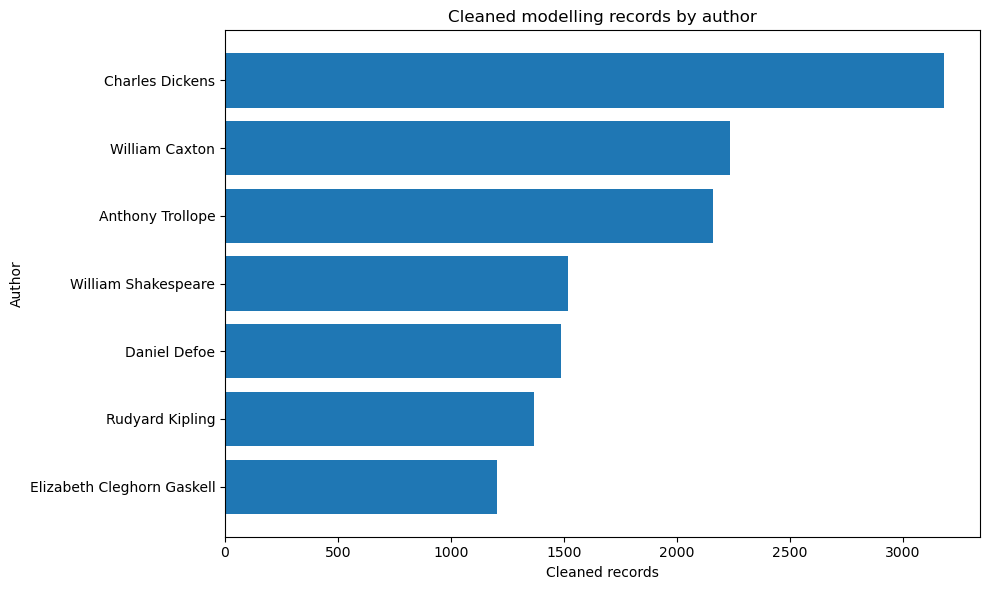

In [13]:
# Cell 14: Cleaned author distribution

cleaned_counts_pd = (
    model_spark_df
    .groupBy("author")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

cleaned_counts_pd["display_author"] = (
    cleaned_counts_pd["author"].map(DISPLAY_NAMES)
)

plt.figure(figsize=(10, 6))
plt.barh(
    cleaned_counts_pd["display_author"][::-1],
    cleaned_counts_pd["count"][::-1]
)
plt.xlabel("Cleaned records")
plt.ylabel("Author")
plt.title("Cleaned modelling records by author")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_04_cleaned_author_counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


,author,distinct_titles,display_author
0,Defoe-Daniel,6,Daniel Defoe
1,anthony-trollope,7,Anthony Trollope
2,charles-dickens,7,Charles Dickens
5,william-shakespeare,8,William Shakespeare
3,elizabeth-cleghorn,14,Elizabeth Cleghorn Gaskell
6,rudyard-kipling,14,Rudyard Kipling
4,william-caxton,17,William Caxton


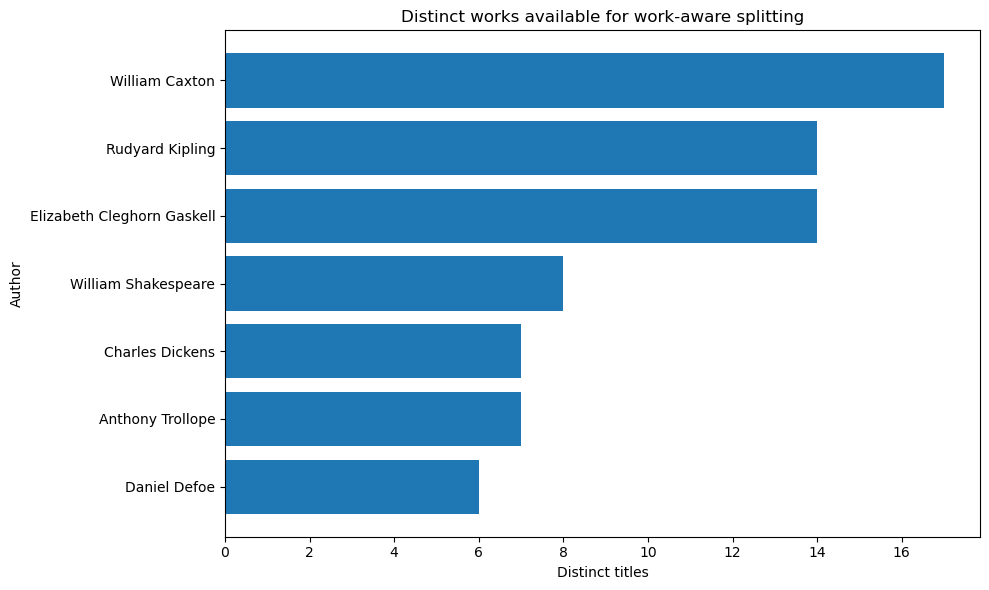

In [14]:
# Cell 15: Distinct title count per author

title_counts_pd = (
    model_spark_df
    .groupBy("author")
    .agg(F.countDistinct("title").alias("distinct_titles"))
    .toPandas()
)

title_counts_pd["display_author"] = (
    title_counts_pd["author"].map(DISPLAY_NAMES)
)

title_counts_pd = title_counts_pd.sort_values(
    "distinct_titles"
)

display(title_counts_pd)

plt.figure(figsize=(10, 6))
plt.barh(
    title_counts_pd["display_author"],
    title_counts_pd["distinct_titles"]
)
plt.xlabel("Distinct titles")
plt.ylabel("Author")
plt.title("Distinct works available for work-aware splitting")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_05_title_diversity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Character length summary


count    13149.000000
mean      2718.982508
std        218.585986
min        222.000000
25%       2599.000000
50%       2691.000000
75%       2799.000000
max       4591.000000
Name: char_length, dtype: float64

Word count summary


count    13149.000000
mean       510.959921
std         18.400957
min         45.000000
25%        512.000000
50%        512.000000
75%        512.000000
max        512.000000
Name: word_count, dtype: float64

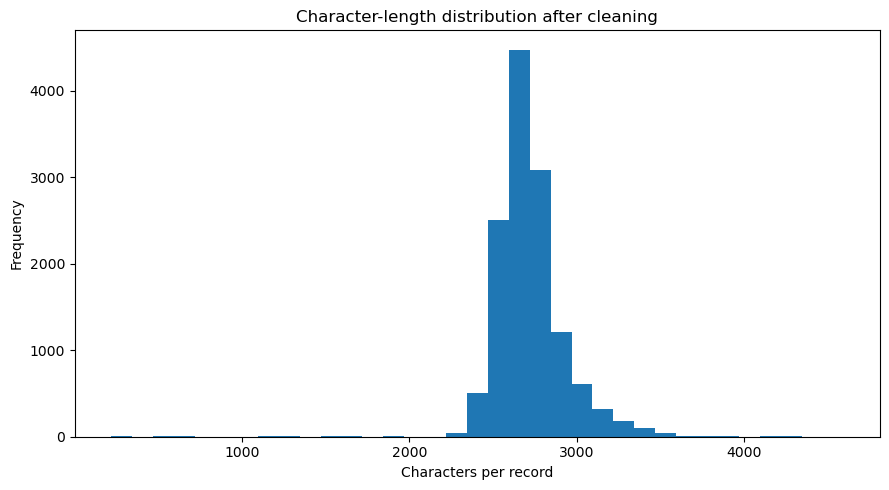

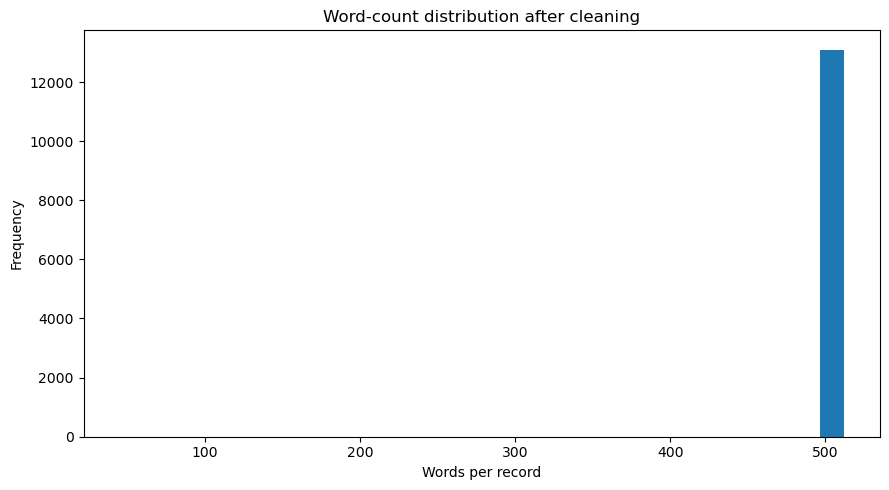

In [16]:
# Cell 16: Text-length EDA

lengths_pd = (
    model_spark_df
    .select("char_length", "word_count")
    .toPandas()
)

print("Character length summary")
display(lengths_pd["char_length"].describe())

print("Word count summary")
display(lengths_pd["word_count"].describe())

plt.figure(figsize=(9, 5))
plt.hist(lengths_pd["char_length"], bins=35)
plt.xlabel("Characters per record")
plt.ylabel("Frequency")
plt.title("Character-length distribution after cleaning")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_06_character_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(lengths_pd["word_count"], bins=30)
plt.xlabel("Words per record")
plt.ylabel("Frequency")
plt.title("Word-count distribution after cleaning")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_07_word_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### EDA findings to carry into modelling

The cleaned class counts are not perfectly equal, so later model comparison will not rely on accuracy alone. Macro F1 and balanced accuracy are included because they give more attention to performance across all seven authors.

The title-diversity check is also important. Different chunks from the same book can share names, characters and repeated vocabulary. A random row split could therefore make the test set too easy. The next stage keeps each `author + title` group in only one partition.

The TextAge records are mostly fixed-length chunks. This means sequence length should be treated as a modelling and computational choice rather than inferred only from the maximum record length.


## 5. Convert the cleaned Spark subset for neural-network training

Spark has now been used for the large-data loading, cleaning and EDA stages required by the assessment. The cleaned subset contains a manageable number of rows, so it is transferred to pandas for title-aware splitting and then to PyTorch tensors for LSTM training.


In [17]:
# Cell 17: Convert the cleaned Spark data to pandas

model_pd = (
    model_spark_df
    .select(
        "text",
        "author",
        "title",
        "category",
        "date",
        "decade",
        "char_length",
        "word_count"
    )
    .toPandas()
)

model_pd = model_pd.reset_index(drop=True)

print("Modelling shape:", model_pd.shape)
display(model_pd.head())


Modelling shape: (13149, 8)


,text,author,title,category,date,decade,char_length,word_count
0,' I have never been here since ' NorI 'The moo...,charles-dickens,Great-expectations,Book,1861,1860,2477,512
1,' I won't talk at all ' said Mrs Brown with an...,charles-dickens,Dombey-and-Son,Book,1846,1840,2626,512
2,' Pitch ' said Mr Toots It seemed to beckon ' ...,charles-dickens,Dombey-and-Son,Book,1846,1840,2798,512
3,' cried Mrs Gamp A rayal gentleman 'She groane...,charles-dickens,martin-chuzzlewit,Book,1844,1840,2674,512
4,15thJune 1706 The Earl ofMar in Name of the Lo...,Defoe-Daniel,A-collection-of-original-papers-and-material-t...,Book,1712,1710,3309,512


## 6. Work-aware train, validation and test split

The target split is approximately 70% training, 15% validation and 15% testing. The split is performed **separately for each author at title level**.

A small random search assigns whole titles to one of the three partitions while trying to keep record counts near the target percentages. Every author must appear in all three partitions. This is more defensible than randomly splitting individual text chunks because it prevents a single literary work from appearing in both training and evaluation data.


In [18]:
# Cell 18: Work-aware per-author title split

def best_title_assignment(author_df, random_seed=42, trials=30_000):
    rng = random.Random(random_seed)

    title_sizes = (
        author_df
        .groupby("title")
        .size()
        .to_dict()
    )

    titles = list(title_sizes.keys())
    n = len(author_df)
    target = np.array([0.70, 0.15, 0.15]) * n

    best = None

    for _ in range(trials):
        assignment = [
            rng.randrange(3)
            for _ in titles
        ]

        # Every partition must receive at least one title.
        if set(assignment) != {0, 1, 2}:
            continue

        counts = np.array([
            sum(
                title_sizes[t]
                for t, split_id in zip(titles, assignment)
                if split_id == j
            )
            for j in range(3)
        ])

        score = (
            np.abs(counts - target).sum() / n
        )

        # Give a large penalty if training receives less than 60%.
        if counts[0] < (0.60 * n):
            score += 1

        if best is None or score < best[0]:
            best = (
                score,
                assignment,
                counts
            )

    if best is None:
        raise RuntimeError(
            "A title-aware split could not be created for this author."
        )

    title_to_split = {
        title: split_id
        for title, split_id
        in zip(titles, best[1])
    }

    return title_to_split


split_parts = []

for author_number, (author, author_df) in enumerate(
    model_pd.groupby("author", sort=True)
):
    title_to_split = best_title_assignment(
        author_df,
        random_seed=SEED + author_number
    )

    part = author_df.copy()

    part["split"] = (
        part["title"]
        .map(title_to_split)
        .map({
            0: "train",
            1: "validation",
            2: "test"
        })
    )

    split_parts.append(part)

split_df = pd.concat(
    split_parts,
    ignore_index=True
)

train_df = (
    split_df[split_df["split"] == "train"]
    .reset_index(drop=True)
)

val_df = (
    split_df[split_df["split"] == "validation"]
    .reset_index(drop=True)
)

test_df = (
    split_df[split_df["split"] == "test"]
    .reset_index(drop=True)
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 9294
Validation: 1869
Test: 1986


In [19]:
# Cell 19: Prove that title groups do not overlap

def group_keys(frame):
    return set(
        frame["author"].astype(str)
        + " || "
        + frame["title"].astype(str)
    )

train_groups = group_keys(train_df)
val_groups = group_keys(val_df)
test_groups = group_keys(test_df)

print(
    "Train-validation overlap:",
    len(train_groups.intersection(val_groups))
)

print(
    "Train-test overlap:",
    len(train_groups.intersection(test_groups))
)

print(
    "Validation-test overlap:",
    len(val_groups.intersection(test_groups))
)

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

for author in SELECTED_AUTHORS:
    assert author in set(train_df["author"])
    assert author in set(val_df["author"])
    assert author in set(test_df["author"])

print("All leakage checks passed.")


Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0
All leakage checks passed.


In [20]:
# Cell 20: Split distribution table

split_author_counts = pd.concat(
    [
        train_df["author"].value_counts().rename("train"),
        val_df["author"].value_counts().rename("validation"),
        test_df["author"].value_counts().rename("test")
    ],
    axis=1
).fillna(0).astype(int)

split_author_counts.index = [
    DISPLAY_NAMES.get(x, x)
    for x in split_author_counts.index
]

display(split_author_counts)

split_author_counts.to_csv(
    OUTPUT_DIR / "split_author_counts.csv"
)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Records": [
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

split_summary["Percentage"] = (
    split_summary["Records"]
    / len(split_df)
    * 100
)

display(split_summary)

split_summary.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False
)


,train,validation,test
Charles Dickens,2159,429,593
William Caxton,1565,345,322
Anthony Trollope,1501,281,379
William Shakespeare,1233,166,120
Daniel Defoe,1040,261,187
Rudyard Kipling,956,205,205
Elizabeth Cleghorn Gaskell,840,182,180


,Split,Records,Percentage
0,Train,9294,70.682181
1,Validation,1869,14.214009
2,Test,1986,15.103810


## 7. Feature preparation

The LSTM receives only the text. The author is the target label.

A word-level tokenizer is built from the **training set only**. Words are converted to integer IDs, infrequent or unseen tokens use an `<UNK>` value, and sequences are padded to a fixed length.

A sequence length of 160 tokens is used as a practical computational compromise for local laptop training. The TextAge records are mostly much longer fixed-size chunks, so using all 512 words would substantially increase recurrent computation. This limitation must be stated in the report because the model sees the opening portion of each chunk rather than every word.


In [21]:
# Cell 21: Encode author labels

label_encoder = LabelEncoder()

label_encoder.fit(
    train_df["author"]
)

y_train = label_encoder.transform(
    train_df["author"]
)

y_val = label_encoder.transform(
    val_df["author"]
)

y_test = label_encoder.transform(
    test_df["author"]
)

class_keys = list(
    label_encoder.classes_
)

class_names = [
    DISPLAY_NAMES[x]
    for x in class_keys
]

NUM_CLASSES = len(class_names)

for i, name in enumerate(class_names):
    print(i, name)


0 Daniel Defoe
1 Anthony Trollope
2 Charles Dickens
3 Elizabeth Cleghorn Gaskell
4 Rudyard Kipling
5 William Caxton
6 William Shakespeare


In [22]:
# Cell 22: Build a training-only vocabulary

TOKEN_PATTERN = re.compile(
    r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[^\w\s]",
    re.UNICODE
)

def tokenize(text):
    return TOKEN_PATTERN.findall(
        str(text).lower()
    )

MAX_VOCAB = 30_000
SEQUENCE_LENGTH = 160

token_counts = Counter()

for text in train_df["text"]:
    token_counts.update(
        tokenize(text)
    )

vocabulary = [
    "<PAD>",
    "<UNK>"
] + [
    token
    for token, count
    in token_counts.most_common(
        MAX_VOCAB - 2
    )
]

token_to_id = {
    token: i
    for i, token
    in enumerate(vocabulary)
}

VOCAB_SIZE = len(vocabulary)

print("Vocabulary size:", VOCAB_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)


Vocabulary size: 30000
Sequence length: 160


In [23]:
# Cell 23: Convert text to padded integer sequences

def encode_text(text):
    token_ids = [
        token_to_id.get(token, 1)
        for token in tokenize(text)[
            :SEQUENCE_LENGTH
        ]
    ]

    if len(token_ids) < SEQUENCE_LENGTH:
        token_ids += [
            0
        ] * (
            SEQUENCE_LENGTH
            - len(token_ids)
        )

    return token_ids


X_train = np.array(
    [encode_text(x) for x in train_df["text"]],
    dtype=np.int32
)

X_val = np.array(
    [encode_text(x) for x in val_df["text"]],
    dtype=np.int32
)

X_test = np.array(
    [encode_text(x) for x in test_df["text"]],
    dtype=np.int32
)

print("Training tensor shape:", X_train.shape)
print("Validation tensor shape:", X_val.shape)
print("Test tensor shape:", X_test.shape)


Training tensor shape: (9294, 160)
Validation tensor shape: (1869, 160)
Test tensor shape: (1986, 160)


In [24]:
# Cell 24: PyTorch DataLoaders

BATCH_SIZE = 256

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(
            np.asarray(y)
        ).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return (
            self.X[index],
            self.y[index]
        )


train_loader = DataLoader(
    TextDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    TextDataset(X_val, y_val),
    batch_size=512,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    TextDataset(X_test, y_test),
    batch_size=512,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created.")


DataLoaders created.


## 8. Baseline LSTM

The baseline model establishes a reference point before improvements are introduced.

Architecture:

`Embedding -> LSTM -> Dense/ReLU -> Dropout -> Author logits`

Cross-entropy loss is used because this is a single-label multiclass problem. Adam is used for optimisation. Validation loss is monitored for early stopping so that training does not simply continue after generalisation begins to worsen.


In [28]:
# Cell 25: Model class

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        bidirectional=False,
        dropout=0.30
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        direction_multiplier = (
            2 if bidirectional else 1
        )

        self.fc1 = nn.Linear(
            hidden_dim * direction_multiplier,
            64
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.output = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):
        embedded = self.embedding(x)

        _, (hidden, _) = self.lstm(
            embedded
        )

        if self.lstm.bidirectional:
            features = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )
        else:
            features = hidden[-1]

        features = self.fc1(features)
        features = self.relu(features)
        features = self.dropout(features)

        return self.output(features)


In [29]:
# Cell 26: Training and evaluation helper functions

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Training device:", DEVICE)


def predict_loader(model, loader):
    model.eval()

    actual = []
    predicted = []
    losses = []

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)

            losses.append(
                criterion(
                    logits,
                    y_batch
                ).item()
            )

            predicted.extend(
                logits.argmax(dim=1)
                .cpu()
                .numpy()
            )

            actual.extend(
                y_batch.cpu().numpy()
            )

    return (
        np.asarray(actual),
        np.asarray(predicted),
        float(np.mean(losses))
    )


def metric_summary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(
            y_true, y_pred
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        )
    }


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    class_weights=None,
    patience=3
):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    criterion = nn.CrossEntropyLoss(
        weight=(
            class_weights.to(DEVICE)
            if class_weights is not None
            else None
        )
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        model.train()

        epoch_losses = []
        epoch_actual = []
        epoch_predicted = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()
            optimizer.step()

            epoch_losses.append(
                loss.item()
            )

            epoch_actual.extend(
                y_batch.cpu().numpy()
            )

            epoch_predicted.extend(
                logits.argmax(dim=1)
                .detach()
                .cpu()
                .numpy()
            )

        val_actual, val_predicted, val_loss = (
            predict_loader(
                model,
                val_loader
            )
        )

        train_accuracy = accuracy_score(
            epoch_actual,
            epoch_predicted
        )

        val_accuracy = accuracy_score(
            val_actual,
            val_predicted
        )

        val_macro_f1 = f1_score(
            val_actual,
            val_predicted,
            average="macro",
            zero_division=0
        )

        history["train_loss"].append(
            float(np.mean(epoch_losses))
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        history["val_macro_f1"].append(
            val_macro_f1
        )

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {history['train_loss'][-1]:.4f} | "
            f"train acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.4f} | "
            f"val macro F1 {val_macro_f1:.4f} | "
            f"{time.time() - start_time:.1f}s"
        )

        if val_loss < (
            best_validation_loss - 1e-4
        ):
            best_validation_loss = val_loss

            best_state = {
                key: value
                .detach()
                .cpu()
                .clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= patience
            ):
                print(
                    "Early stopping activated."
                )
                break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return model, history


Training device: cpu


In [30]:
# Cell 27: Train the baseline model

baseline_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=32,
    num_classes=NUM_CLASSES,
    bidirectional=False,
    dropout=0.30
)

print(baseline_model)

baseline_model, baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=8,
    learning_rate=0.001,
    class_weights=None,
    patience=3
)


LSTMClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (lstm): LSTM(64, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=64, out_features=7, bias=True)
)
Epoch 01 | train loss 1.9157 | train acc 0.1943 | val loss 1.8873 | val acc 0.2370 | val macro F1 0.0820 | 2.9s
Epoch 02 | train loss 1.8731 | train acc 0.2614 | val loss 1.8183 | val acc 0.3232 | val macro F1 0.1466 | 2.6s
Epoch 03 | train loss 1.6691 | train acc 0.3681 | val loss 1.5395 | val acc 0.4093 | val macro F1 0.2579 | 2.6s
Epoch 04 | train loss 1.4950 | train acc 0.4139 | val loss 1.4522 | val acc 0.4211 | val macro F1 0.2558 | 2.5s
Epoch 05 | train loss 1.3697 | train acc 0.4524 | val loss 1.3319 | val acc 0.4446 | val macro F1 0.3087 | 2.4s
Epoch 06 | train loss 1.2854 | train acc 0.4998 | val loss 1.4207 | val acc 0.3938 | val macro F1 0.3011 | 2.5s
Epoch 07 | train loss 1.2096 | train

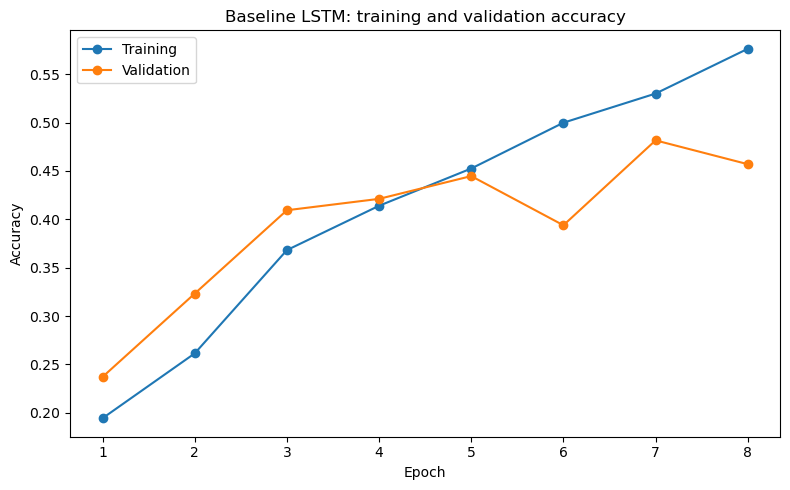

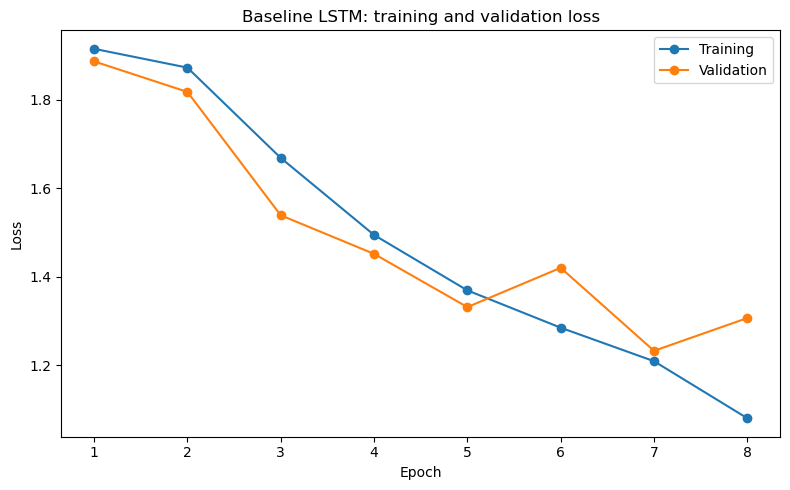

In [31]:
# Cell 28: Baseline training curves

def plot_training_history(
    history,
    model_label,
    file_prefix
):
    epochs = np.arange(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training"
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{model_label}: training and validation accuracy"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{file_prefix}_accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training"
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_label}: training and validation loss"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{file_prefix}_loss.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


plot_training_history(
    baseline_history,
    "Baseline LSTM",
    "figure_08_baseline"
)


In [32]:
# Cell 29: Baseline validation metrics

baseline_val_actual, baseline_val_predicted, _ = (
    predict_loader(
        baseline_model,
        val_loader
    )
)

baseline_val_metrics = metric_summary(
    baseline_val_actual,
    baseline_val_predicted
)

display(
    pd.DataFrame(
        [baseline_val_metrics]
    )
)


,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,0.481541,0.333683,0.429641,0.370409,0.429641


## 9. Improved bidirectional LSTM

The second model introduces controlled changes rather than simply increasing complexity without justification.

Changes include:

- a larger embedding layer;
- a bidirectional LSTM;
- stronger dropout;
- class-weighted loss based on training frequencies; and
- a lower learning rate.

The purpose is to test whether additional contextual capacity and class balancing improve performance across all authors. Model selection is based on **validation macro F1**, not the test set.


In [34]:
# Cell 30: Training class weights

class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

class_weights_np = (
    len(y_train)
    / (
        NUM_CLASSES
        * class_counts
    )
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32
)

weight_table = pd.DataFrame({
    "Author": class_names,
    "Training records": class_counts,
    "Class weight": class_weights_np
})

display(weight_table)

weight_table.to_csv(
    OUTPUT_DIR / "class_weights.csv",
    index=False
)


,Author,Training records,Class weight
0,Daniel Defoe,1040,1.276648
1,Anthony Trollope,1501,0.884553
2,Charles Dickens,2159,0.614967
3,Elizabeth Cleghorn Gaskell,840,1.580612
4,Rudyard Kipling,956,1.388822
5,William Caxton,1565,0.848380
6,William Shakespeare,1233,1.076816


In [35]:
# Cell 31: Train the improved model

improved_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=96,
    hidden_dim=32,
    num_classes=NUM_CLASSES,
    bidirectional=True,
    dropout=0.50
)

print(improved_model)

improved_model, improved_history = train_model(
    improved_model,
    train_loader,
    val_loader,
    epochs=12,
    learning_rate=0.0005,
    class_weights=class_weights,
    patience=4
)


LSTMClassifier(
  (embedding): Embedding(30000, 96, padding_idx=0)
  (lstm): LSTM(96, 32, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=64, out_features=7, bias=True)
)
Epoch 01 | train loss 1.9472 | train acc 0.1474 | val loss 1.9346 | val acc 0.1750 | val macro F1 0.1075 | 5.5s
Epoch 02 | train loss 1.9360 | train acc 0.1850 | val loss 1.9256 | val acc 0.2071 | val macro F1 0.1578 | 5.2s
Epoch 03 | train loss 1.9189 | train acc 0.2234 | val loss 1.9071 | val acc 0.2365 | val macro F1 0.2013 | 5.7s
Epoch 04 | train loss 1.8799 | train acc 0.2601 | val loss 1.8482 | val acc 0.2616 | val macro F1 0.2209 | 5.3s
Epoch 05 | train loss 1.7573 | train acc 0.3064 | val loss 1.6727 | val acc 0.2916 | val macro F1 0.2151 | 5.3s
Epoch 06 | train loss 1.4811 | train acc 0.3750 | val loss 1.6709 | val acc 0.3264 | val macro F1 0.3102 | 5.2s
Epoch 07 | train

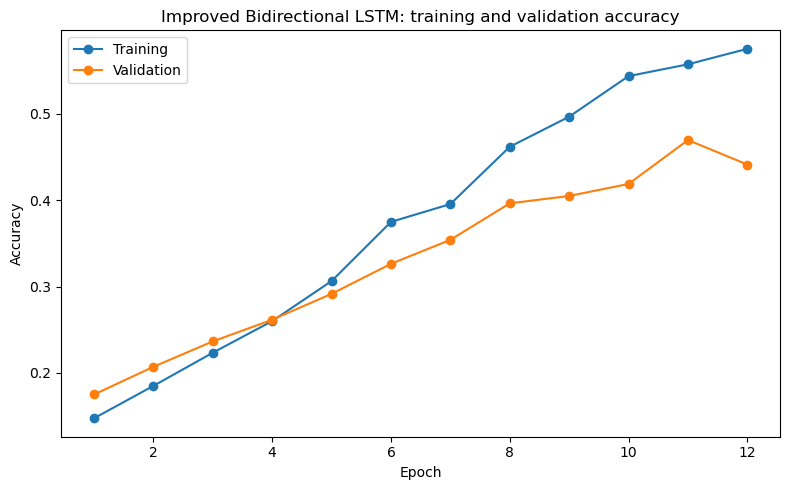

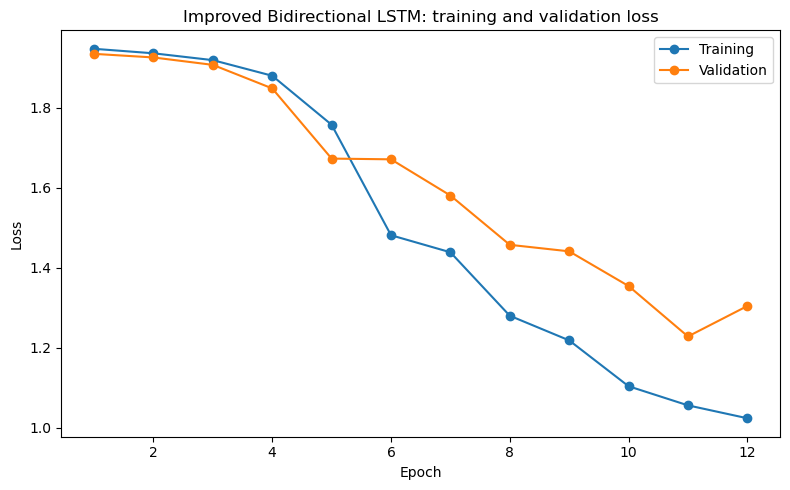

In [36]:
# Cell 32: Improved model training curves

plot_training_history(
    improved_history,
    "Improved Bidirectional LSTM",
    "figure_09_improved"
)


In [37]:
# Cell 33: Improved model validation metrics

improved_val_actual, improved_val_predicted, _ = (
    predict_loader(
        improved_model,
        val_loader
    )
)

improved_val_metrics = metric_summary(
    improved_val_actual,
    improved_val_predicted
)

display(
    pd.DataFrame(
        [improved_val_metrics]
    )
)


,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,0.46977,0.453296,0.47819,0.449457,0.47819


## 10. Validation-led model comparison

The test set remains untouched during model development. Baseline and improved models are compared using the validation set.

Macro F1 is the main selection metric because it averages author-level performance equally. Accuracy and balanced accuracy are included as supporting measures.


In [38]:
# Cell 34: Compare the two models on validation data

validation_comparison = pd.DataFrame([
    {
        "model": "Baseline LSTM",
        **baseline_val_metrics
    },
    {
        "model": "Improved Bidirectional LSTM",
        **improved_val_metrics
    }
])

validation_comparison = (
    validation_comparison
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(validation_comparison)

validation_comparison.to_csv(
    OUTPUT_DIR / "validation_model_comparison.csv",
    index=False
)

best_model_name = (
    validation_comparison
    .loc[0, "model"]
)

selected_model = (
    improved_model
    if best_model_name
    == "Improved Bidirectional LSTM"
    else baseline_model
)

print("Selected model:", best_model_name)


,model,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,Improved Bidirectional LSTM,0.469770,0.453296,0.478190,0.449457,0.478190
1,Baseline LSTM,0.481541,0.333683,0.429641,0.370409,0.429641


Selected model: Improved Bidirectional LSTM


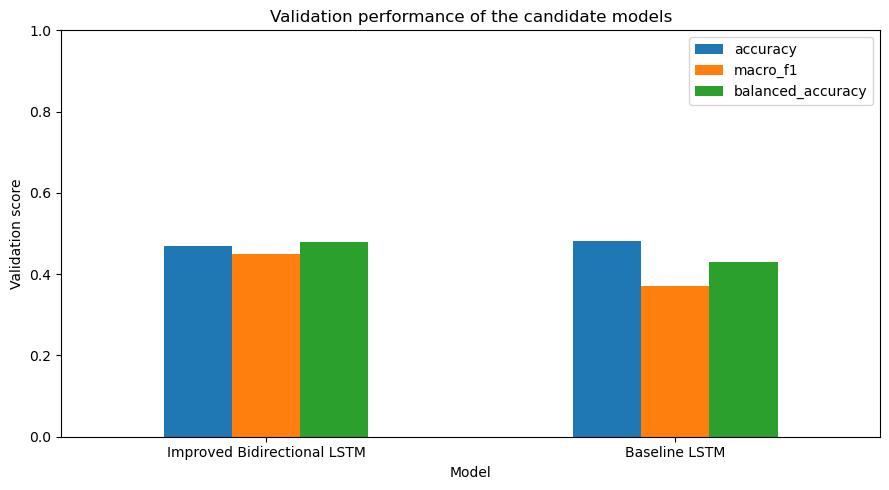

In [39]:
# Cell 35: Validation comparison graph

comparison_plot = (
    validation_comparison
    .set_index("model")[
        [
            "accuracy",
            "macro_f1",
            "balanced_accuracy"
        ]
    ]
)

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Validation score")
plt.xlabel("Model")
plt.title("Validation performance of the candidate models")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_10_validation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 11. Final evaluation on the untouched test set

Only the selected model is now evaluated on the test set.

The final report must use these results for its main client-facing conclusion. Training accuracy is not evidence of generalisation.

Evaluation includes:

- accuracy;
- macro precision;
- macro recall;
- macro F1;
- balanced accuracy;
- per-author classification report; and
- normalised confusion matrix.


In [40]:
# Cell 36: Final test metrics

test_actual, test_predicted, _ = (
    predict_loader(
        selected_model,
        test_loader
    )
)

final_test_metrics = metric_summary(
    test_actual,
    test_predicted
)

final_test_metrics_df = pd.DataFrame(
    [{
        "model": best_model_name,
        **final_test_metrics
    }]
)

display(final_test_metrics_df)

final_test_metrics_df.to_csv(
    OUTPUT_DIR / "final_test_metrics.csv",
    index=False
)


,model,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,Improved Bidirectional LSTM,0.439074,0.44284,0.47787,0.442899,0.47787


In [41]:
# Cell 37: Full per-author classification report

report_text = classification_report(
    test_actual,
    test_predicted,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)

report_df = pd.DataFrame(
    classification_report(
        test_actual,
        test_predicted,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(report_df)

report_df.to_csv(
    OUTPUT_DIR / "final_classification_report.csv"
)


                            precision    recall  f1-score   support

              Daniel Defoe     0.2313    0.1658    0.1931       187
          Anthony Trollope     0.4084    0.4881    0.4447       379
           Charles Dickens     0.4414    0.2159    0.2899       593
Elizabeth Cleghorn Gaskell     0.1893    0.2556    0.2175       180
           Rudyard Kipling     0.2578    0.5220    0.3452       205
            William Caxton     0.9681    0.8478    0.9040       322
       William Shakespeare     0.6036    0.8500    0.7059       120

                  accuracy                         0.4391      1986
                 macro avg     0.4428    0.4779    0.4429      1986
              weighted avg     0.4687    0.4391    0.4342      1986



,precision,recall,f1-score,support
Daniel Defoe,0.231343,0.165775,0.193146,187.000000
Anthony Trollope,0.408389,0.488127,0.444712,379.000000
Charles Dickens,0.441379,0.215852,0.289921,593.000000
Elizabeth Cleghorn Gaskell,0.189300,0.255556,0.217494,180.000000
Rudyard Kipling,0.257831,0.521951,0.345161,205.000000
William Caxton,0.968085,0.847826,0.903974,322.000000
William Shakespeare,0.603550,0.850000,0.705882,120.000000
accuracy,0.439074,0.439074,0.439074,0.439074
macro avg,0.442840,0.477870,0.442899,1986.000000
weighted avg,0.468710,0.439074,0.434179,1986.000000


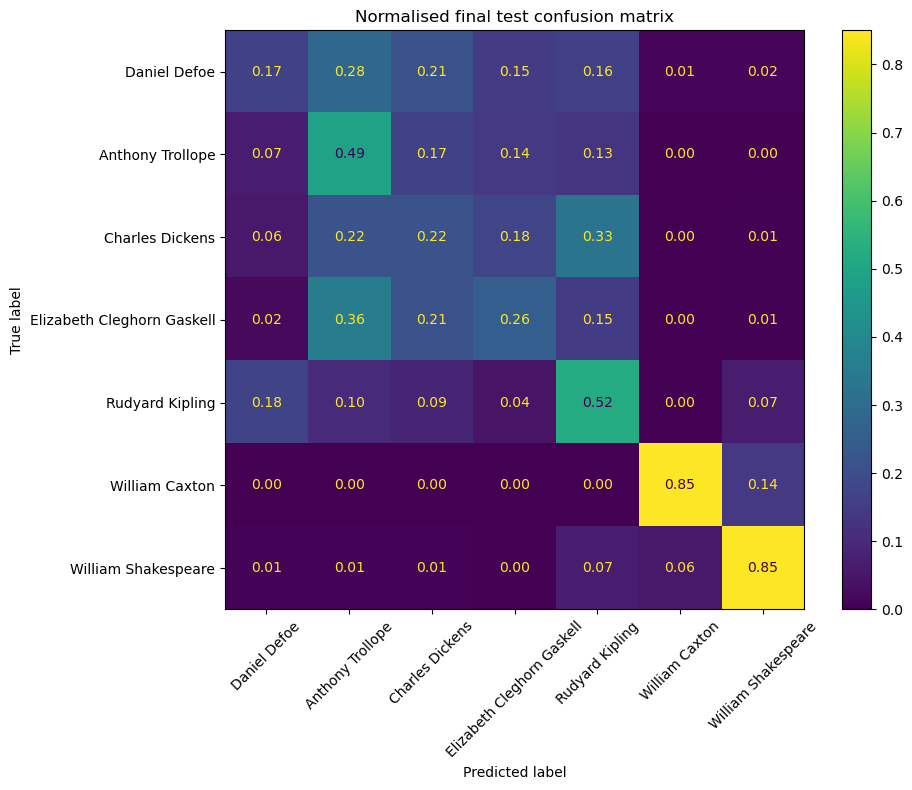

In [42]:
# Cell 38: Normalised confusion matrix

normalised_cm = confusion_matrix(
    test_actual,
    test_predicted,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ConfusionMatrixDisplay(
    confusion_matrix=normalised_cm,
    display_labels=class_names
).plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Normalised final test confusion matrix"
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_11_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [43]:
# Cell 39: Strongest, weakest and largest pairwise confusion

report_dict = classification_report(
    test_actual,
    test_predicted,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

author_rows = []

for author in class_names:
    author_rows.append({
        "author": author,
        "precision": report_dict[author]["precision"],
        "recall": report_dict[author]["recall"],
        "f1_score": report_dict[author]["f1-score"],
        "support": int(report_dict[author]["support"])
    })

author_performance = pd.DataFrame(
    author_rows
).sort_values(
    "f1_score",
    ascending=False
)

display(author_performance)

cm_counts = confusion_matrix(
    test_actual,
    test_predicted
)

cm_errors = cm_counts.copy()
np.fill_diagonal(cm_errors, 0)

true_index, predicted_index = np.unravel_index(
    np.argmax(cm_errors),
    cm_errors.shape
)

print(
    "Strongest author by F1:",
    author_performance.iloc[0]["author"]
)

print(
    "Weakest author by F1:",
    author_performance.iloc[-1]["author"]
)

print("Largest pairwise confusion:")
print("True author:", class_names[true_index])
print("Predicted as:", class_names[predicted_index])
print("Cases:", cm_errors[true_index, predicted_index])

author_performance.to_csv(
    OUTPUT_DIR / "author_performance.csv",
    index=False
)


,author,precision,recall,f1_score,support
5,William Caxton,0.968085,0.847826,0.903974,322
6,William Shakespeare,0.603550,0.850000,0.705882,120
1,Anthony Trollope,0.408389,0.488127,0.444712,379
4,Rudyard Kipling,0.257831,0.521951,0.345161,205
2,Charles Dickens,0.441379,0.215852,0.289921,593
3,Elizabeth Cleghorn Gaskell,0.189300,0.255556,0.217494,180
0,Daniel Defoe,0.231343,0.165775,0.193146,187


Strongest author by F1: William Caxton
Weakest author by F1: Daniel Defoe
Largest pairwise confusion:
True author: Charles Dickens
Predicted as: Rudyard Kipling
Cases: 193


## 12. Demonstrate the author-guessing bot

The final model is now wrapped in a simple prediction function. A passage from the held-out test set is used for demonstration so that the example was not part of model training.


In [44]:
# Cell 40: Prediction function and held-out example

def predict_author(text):
    selected_model.eval()

    encoded = np.array(
        [encode_text(text)],
        dtype=np.int32
    )

    tensor = torch.from_numpy(
        encoded
    ).long().to(DEVICE)

    with torch.no_grad():
        logits = selected_model(
            tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted_index = int(
        torch.argmax(
            probabilities
        ).item()
    )

    return {
        "predicted_author": class_names[predicted_index],
        "confidence": float(
            probabilities[predicted_index]
            .cpu()
            .item()
        )
    }


example_text = test_df.iloc[0]["text"]
actual_author = DISPLAY_NAMES[
    test_df.iloc[0]["author"]
]

prediction = predict_author(
    example_text
)

print("Actual author:", actual_author)
print(
    "Predicted author:",
    prediction["predicted_author"]
)
print(
    "Confidence:",
    f"{prediction['confidence']:.2%}"
)


Actual author: Daniel Defoe
Predicted author: William Shakespeare
Confidence: 56.09%


## 13. Save the experiment evidence

The final cell saves the main experimental settings and metrics. The `part1_outputs` folder should be kept with the notebook because it contains the figures and tables that must be inserted and discussed in the final report.


In [45]:
# Cell 41: Save experiment summary

experiment_summary = {
    "dataset": "TextAge Dataset",
    "source_file": str(CSV_PATH),
    "final_modelling_records": int(
        len(model_pd)
    ),
    "train_records": int(
        len(train_df)
    ),
    "validation_records": int(
        len(val_df)
    ),
    "test_records": int(
        len(test_df)
    ),
    "vocabulary_size": int(
        VOCAB_SIZE
    ),
    "sequence_length": int(
        SEQUENCE_LENGTH
    ),
    "selected_model": best_model_name,
    "final_test_metrics": {
        key: float(value)
        for key, value
        in final_test_metrics.items()
    }
}

with open(
    OUTPUT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=4
    )

print(
    json.dumps(
        experiment_summary,
        indent=4
    )
)

print("\nFiles created:")
for file in sorted(
    OUTPUT_DIR.iterdir()
):
    print(file.name)


{
    "dataset": "TextAge Dataset",
    "source_file": "textage_data\\textage_large.csv",
    "final_modelling_records": 13149,
    "train_records": 9294,
    "validation_records": 1869,
    "test_records": 1986,
    "vocabulary_size": 30000,
    "sequence_length": 160,
    "selected_model": "Improved Bidirectional LSTM",
    "final_test_metrics": {
        "accuracy": 0.4390735146022155,
        "macro_precision": 0.44283975056614644,
        "macro_recall": 0.4778695020277025,
        "macro_f1": 0.4428985605344115,
        "balanced_accuracy": 0.4778695020277025
    }
}

Files created:
author_performance.csv
class_weights.csv
cleaning_summary.csv
experiment_summary.json
figure_01_top_authors.png
figure_02_category_distribution.png
figure_04_cleaned_author_counts.png
figure_05_title_diversity.png
figure_06_character_length_distribution.png
figure_07_word_count_distribution.png
figure_08_baseline_accuracy.png
figure_08_baseline_loss.png
figure_09_improved_accuracy.png
figure_09_improv